# Classification · Quels clients vont résilier ?

[![Ouvrir dans Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josephazar/ELC2-Introduction-IA-2026/blob/main/seance-2/ia-elc2/03-classification.ipynb)

**ELC2 · Introduction au machine learning · Séance 2**

Comtoise Télécom, un opérateur internet et mobile fictif de Franche-Comté, perd des clients
chaque mois. L'entreprise voudrait repérer ceux qui vont partir, avant leur départ, pour leur
proposer une offre. C'est un problème de **classification** : pour chaque client, prédire une
catégorie, *résilie* ou *reste*.

Ce notebook fait deux choses.

1. **Il refait la préparation de la séance 1** sur un nouveau fichier : doublons, variables
   dépendante et indépendantes, distributions, valeurs aberrantes, cases vides, mise à
   l'échelle, texte à encoder.
2. **Il prépare ces données pour la classification** : découpage en train et test, préparation
   apprise sur le train seulement, trois classifieurs, mesure des résultats, matrice de confusion.

Vous n'avez **rien à écrire** : il suffit d'exécuter les cellules, dans l'ordre, avec
**Maj + Entrée** dans Jupyter (**Exécution → Tout exécuter** sur Google Colab). Sur GitHub, le
notebook s'affiche avec ses résultats : il se lit comme un guide.

## 0. Vérifier que tout est prêt

Cette cellule dit où tourne votre notebook. Sur votre ordinateur, ce doit être le Python du
dossier `.venv` de votre dossier `ia-elc2`. Sur Google Colab, il n'y a rien à vérifier.

In [1]:
import sys
from pathlib import Path

python_utilise = Path(sys.executable)

if "google.colab" in sys.modules:
    print("OK : vous êtes sur Google Colab, il n'y a rien à installer.")
elif ".venv" in python_utilise.parts:
    print("Python utilisé :", ".../" + "/".join(python_utilise.parts[-4:]))
    print("OK : ce notebook tourne dans l'environnement virtuel du cours.")
else:
    print("Python utilisé :", python_utilise)
    print("ATTENTION : ce n'est pas le Python du cours. Relisez le guide d'installation.")

Python utilisé : .../ia-elc2/.venv/bin/python
OK : ce notebook tourne dans l'environnement virtuel du cours.


Le fichier des clients est-il là ? Sur votre ordinateur, il est dans le dossier `donnees`.
Sur Google Colab, cette cellule le télécharge depuis la page GitHub du cours.

In [2]:
from urllib.request import urlretrieve

fichier = Path("donnees/clients-comtoise-telecom.xlsx")
if not fichier.exists():
    fichier.parent.mkdir(exist_ok=True)
    urlretrieve("https://raw.githubusercontent.com/josephazar/ELC2-Introduction-IA-2026/main/seance-2/ia-elc2/donnees/clients-comtoise-telecom.xlsx", fichier)
    print("Fichier téléchargé depuis GitHub.")

print("Données prêtes :", fichier)

Données prêtes : donnees/clients-comtoise-telecom.xlsx


On charge les bibliothèques, et on règle l'allure des graphiques une fois pour toutes.

In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# avertissement sans conséquence, que certaines versions de scikit-learn affichent avec la régression logistique
warnings.filterwarnings("ignore", message="Unknown solver options")

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})
BLEU, ORANGE = "#2f6fb0", "#d9822b"
pd.set_option("display.max_colwidth", 90)

---
# Partie 1 · Le rappel de la séance 1

Tout ce que nous avons fait sur le fichier de Comtoise Auto Occasion (séance 1), refait sur un
nouveau fichier.
Dans cette partie, on **regarde** chaque technique sur le fichier entier. La partie 2 explique
pourquoi, pour classer, il faudra la refaire autrement.

## 1. Regarder avant de toucher

In [4]:
clients = pd.read_excel("donnees/clients-comtoise-telecom.xlsx")
clients.head(10)

,id_client,age,ville,anciennete_mois,contrat,mode_paiement,mensualite,conso_go,nb_appels_support,satisfaction,motif_resiliation,resilie
0,C-0001,35.0,Dole,18,2 ans,Prélèvement,43.25,68.9,3,Neutre,NaN,Non
1,C-0002,49.0,Besançon,43,1 an,Virement,34.17,139.1,2,Satisfait,NaN,Non
2,C-0003,19.0,Montbéliard,26,1 an,Prélèvement,50.24,68.4,1,NaN,Prix trop élevé,Oui
3,C-0004,NaN,Vesoul,62,Mensuel,Prélèvement,30.44,343.9,0,NaN,NaN,Non
4,C-0005,55.0,Pontarlier,15,Mensuel,Prélèvement,29.52,143.5,4,Neutre,Prix trop élevé,Oui
5,C-0006,42.0,Besançon,49,2 ans,Prélèvement,48.02,159.7,1,Satisfait,NaN,Non
6,C-0007,42.0,Besançon,25,2 ans,Prélèvement,44.82,99.7,3,Très insatisfait,Qualité du service,Oui
7,C-0008,NaN,Besançon,60,2 ans,Carte bancaire,35.45,84.5,1,Satisfait,NaN,Non
8,C-0009,42.0,Belfort,5,Mensuel,Chèque,34.41,464.0,0,Très satisfait,Déménagement,Oui
9,C-0010,43.0,Belfort,31,Mensuel,Carte bancaire,33.91,121.3,2,Satisfait,NaN,Non


Une ligne par client. Les cases vides s'affichent `NaN` : c'est la façon qu'a Python d'écrire
« rien ». Combien de lignes et de colonnes en tout ?

In [5]:
clients.shape

(1512, 12)

Le fichier a un deuxième onglet, le **dictionnaire** : il dit ce que veut dire chaque colonne,
et surtout le **rôle** qu'elle jouera.

In [6]:
pd.read_excel("donnees/clients-comtoise-telecom.xlsx", sheet_name="dictionnaire")

,colonne,signification,type,rôle,valeurs
0,id_client,Numéro du client,texte,identifiant,ne décrit pas le client : à retirer
1,age,Âge du client,nombre,caractéristique (X),en années
2,ville,Ville de l'agence,texte,caractéristique (X),"Besançon, Belfort, Montbéliard, Dole, Vesoul, Pontarlier"
3,anciennete_mois,Depuis combien de mois est-il client,nombre,caractéristique (X),en mois
4,contrat,Durée d'engagement du contrat,texte,caractéristique (X),Mensuel < 1 an < 2 ans
5,mode_paiement,Comment il paie,texte,caractéristique (X),"Prélèvement, Carte bancaire, Virement, Chèque"
6,mensualite,Montant de l'abonnement,nombre,caractéristique (X),en euros par mois
7,conso_go,Données consommées par mois,nombre,caractéristique (X),en gigaoctets (Go)
8,nb_appels_support,Appels au support sur les 6 derniers mois,nombre,caractéristique (X),"0, 1, 2..."
9,satisfaction,Réponse à l'enquête de satisfaction,texte,caractéristique (X),Très insatisfait < Insatisfait < Neutre < Satisfait < Très satisfait (beaucoup de clie...


## 2. Les doublons

Combien de lignes sont la copie exacte d'une ligne déjà vue ?

In [7]:
print("Doublons :", clients.duplicated().sum())

Doublons : 12


Voici quelques clients qui apparaissent deux fois, côte à côte :

In [8]:
repetes = clients[clients["id_client"].duplicated(keep=False)].sort_values("id_client")
repetes.head(6)

,id_client,age,ville,anciennete_mois,contrat,mode_paiement,mensualite,conso_go,nb_appels_support,satisfaction,motif_resiliation,resilie
1421,C-0348,44.0,Dole,28,1 an,Prélèvement,43.84,167.7,2,Satisfait,NaN,Non
349,C-0348,44.0,Dole,28,1 an,Prélèvement,43.84,167.7,2,Satisfait,NaN,Non
404,C-0403,48.0,Dole,80,Mensuel,Prélèvement,42.43,480.1,1,NaN,Prix trop élevé,Oui
665,C-0403,48.0,Dole,80,Mensuel,Prélèvement,42.43,480.1,1,NaN,Prix trop élevé,Oui
897,C-0591,33.0,Belfort,79,Mensuel,Prélèvement,NaN,284.8,0,Très satisfait,NaN,Non
593,C-0591,33.0,Belfort,79,Mensuel,Prélèvement,NaN,284.8,0,Très satisfait,NaN,Non


Un même client compté deux fois pèse double dans le modèle. On garde un exemplaire de chaque
ligne, puis on recompte.

In [9]:
clients = clients.drop_duplicates().reset_index(drop=True)
len(clients)

1500

## 3. Qui prédit qui ? Variable dépendante et variables indépendantes

| | Autres noms | Ce que c'est | Dans ce fichier |
|---|---|---|---|
| **Variable dépendante** | cible, `y` | ce qu'on veut **prédire**. Elle *dépend* des autres | `resilie` |
| **Variables indépendantes** | caractéristiques, *features*, `X` | ce qu'on **connaît** du client, au moment de prédire | `age`, `ville`, `contrat`... |

Deux colonnes ne sont ni l'une ni l'autre. Regardons d'abord la cible : combien de clients
résilient ?

In [10]:
effectifs = clients["resilie"].value_counts()
pd.DataFrame({"clients": effectifs, "part": (effectifs / len(clients)).round(3)})

,clients,part
resilie,,
Non,1107,0.738
Oui,393,0.262


Environ un client sur quatre part. Les deux classes ne sont pas à égalité, et cela change la
façon de lire les résultats : nous y reviendrons au moment de mesurer le modèle.

Dans la suite, **1 veut dire « résilie »**. C'est la **classe positive** : l'événement que l'on
cherche à détecter.

### Les deux colonnes à écarter

- `id_client` est un numéro. Il ne décrit pas le client : un modèle pourrait l'apprendre par
  cœur, sans rien comprendre.
- `motif_resiliation` n'est rempli que pour les clients **partis**. Elle est vide pour tous les
  autres :

In [11]:
pd.crosstab(clients["resilie"], clients["motif_resiliation"].notna(), colnames=["motif renseigné ?"])

motif renseigné ?,False,True
resilie,,
Non,1107,0
Oui,0,393


Colonne remplie si et seulement si le client est parti : c'est la **réponse déguisée en
question**. Un modèle qui l'utiliserait serait parfait sur ce fichier et inutile dans la vraie
vie, car au moment de décider, le client n'est pas encore parti. Une caractéristique doit
être **connue avant** l'événement qu'on prédit.

On sépare donc les deux : `y` est la cible (1 = résilie), `X` rassemble les variables
indépendantes.

In [12]:
y = (clients["resilie"] == "Oui").astype(int)
X = clients.drop(columns=["resilie", "id_client", "motif_resiliation"])
X.columns.tolist()

['age',
 'ville',
 'anciennete_mois',
 'contrat',
 'mode_paiement',
 'mensualite',
 'conso_go',
 'nb_appels_support',
 'satisfaction']

## 4. Les distributions

On commence par les colonnes numériques. `describe()` résume chacune : nombre de valeurs
(`count`), moyenne (`mean`), écart-type (`std`), minimum, quartiles (`25%`, `50%` = la
médiane, `75%`) et maximum.

In [13]:
colonnes_nombres = ["age", "anciennete_mois", "mensualite", "conso_go", "nb_appels_support"]
X[colonnes_nombres].describe().round(1)

,age,anciennete_mois,mensualite,conso_go,nb_appels_support
count,1440.0,1500.0,1485.0,1455.0,1500.0
mean,46.1,29.1,45.8,2270.6,1.2
std,15.3,21.0,156.5,45367.3,1.1
min,0.0,1.0,16.8,10.9,0.0
25%,36.0,13.0,34.8,93.8,0.0
50%,46.0,25.0,40.2,155.9,1.0
75%,55.0,40.0,45.4,262.9,2.0
max,230.0,96.0,4590.0,999999.0,6.0


Regardez la ligne `max` : un client de **230 ans**, un abonnement à **4 590 € par mois**, une
consommation de **999 999 Go**. Ce sont des erreurs. Et elles abîment le dessin : voici
l'histogramme de `conso_go`, tel quel.

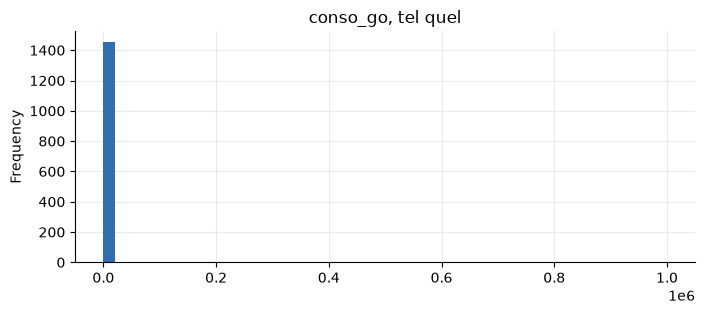

In [14]:
X["conso_go"].plot(kind="hist", bins=50, figsize=(8, 3), color=BLEU, title="conso_go, tel quel")
plt.show()

Une seule barre : les trois valeurs à 999 999 écrasent tout le reste. Pour voir la **vraie
forme**, on dessine seulement la zone où se trouvent presque tous les clients (les valeurs en
dehors seront examinées à l'étape suivante).

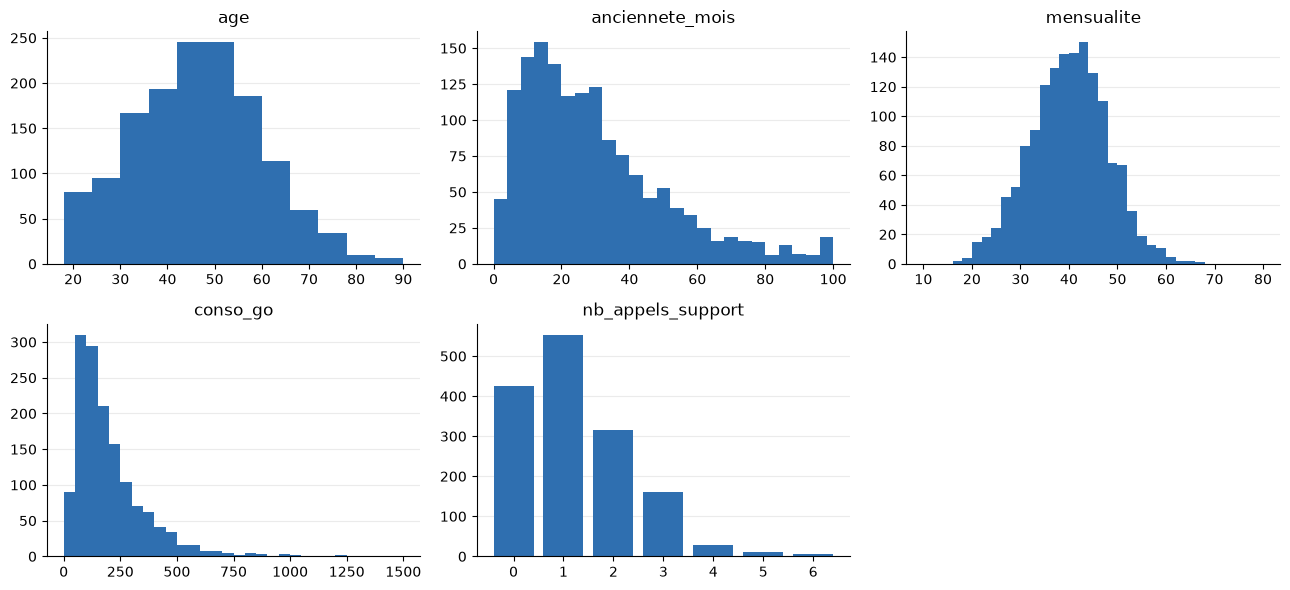

In [15]:
# colonne : (zone dessinée, nombre de barres)
zones = {
    "age": ((18, 90), 12),
    "anciennete_mois": ((0, 100), 25),
    "mensualite": ((10, 80), 35),
    "conso_go": ((0, 1500), 30),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (colonne, (zone, barres)) in zip(axes.flat, zones.items()):
    ax.hist(X[colonne].dropna(), bins=barres, range=zone, color=BLEU)
    ax.set_title(colonne)

appels = X["nb_appels_support"].value_counts().sort_index()
axes[1, 1].bar(appels.index, appels.values, color=BLEU)
axes[1, 1].set_title("nb_appels_support")
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

Quatre formes différentes :

- `age` et `mensualite` : en **cloche**. Beaucoup de valeurs au centre, de moins en moins vers
  les bords, de façon symétrique.
- `anciennete_mois` : **étalée vers la droite**. Beaucoup de clients récents, peu de clients
  anciens.
- `conso_go` : **très étalée vers la droite**. La plupart des clients consomment peu, quelques
  gros consommateurs forment une longue queue.
- `nb_appels_support` : des petits **nombres entiers**.

Cette forme n'est pas un détail : elle décide de **la méthode** pour repérer les valeurs
aberrantes.

## 5. Les valeurs aberrantes : z-score ou quartiles ?

Deux méthodes, vues en séance 1.

- Le **z-score** dit à combien d'écarts-types une valeur se trouve de la moyenne :
  z = (x − moyenne) ÷ écart-type. Au-delà de 3, c'est très rare **si la colonne est en cloche**.
- Les **quartiles** (règle de Tukey) ne supposent aucune forme : on signale ce qui sort de
  [Q1 − 1,5 × IQR ; Q3 + 1,5 × IQR].

On écrit les deux une fois pour toutes.

In [16]:
def z_score(colonne):
    # écart-type calculé en divisant par n, comme au tableau
    return (colonne - colonne.mean()) / colonne.std(ddof=0)


def bornes_quartiles(colonne):
    q1, q3 = colonne.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

### Sur une colonne en cloche : le z-score

`age` a la forme d'une cloche. Quels clients ont un |z| supérieur à 3 ?

In [17]:
z_age = z_score(X["age"])
signales = pd.DataFrame({"age": X["age"], "z": z_age.round(1)})[z_age.abs() > 3]
signales.sort_values("age")

,age,z
345,0.0,-3.0
772,0.0,-3.0
1241,150.0,6.8
707,175.0,8.4
546,230.0,12.0


Cinq clients, et ce sont **tous** des erreurs : 230, 175 et 150 ans sont des fautes de frappe,
et deux âges à **0** sont un code « inconnu » (ils dépassent le seuil de justesse : z = −3,0). La règle
fait ce qu'on attend d'elle.

Même chose sur la mensualité, l'autre colonne en cloche :

In [18]:
z_mensualite = z_score(X["mensualite"])
signales = pd.DataFrame({"mensualite": X["mensualite"], "z": z_mensualite.round(1)})[z_mensualite.abs() > 3]
signales

,mensualite,z
18,3990.0,25.2
1057,4590.0,29.0


3 990 € et 4 590 € : la virgule oubliée de 39,90 € et de 45,90 €. Là encore, ce sont des erreurs.

### Sur une colonne étalée : le z-score se fait avoir

Appliquons la même règle à `conso_go`.

In [19]:
z_conso = z_score(X["conso_go"])
print("moyenne :", round(X["conso_go"].mean()), "Go     écart-type :", round(X["conso_go"].std(ddof=0)), "Go")

pd.DataFrame({"conso_go": X["conso_go"], "z": z_conso.round(2)}).nlargest(8, "conso_go")

moyenne : 2271 Go     écart-type : 45352 Go


,conso_go,z
521,999999.0,22.00
977,999999.0,22.00
982,999999.0,22.00
794,2504.4,0.01
1021,1743.3,-0.01
1014,1594.5,-0.01
761,1413.2,-0.02
894,1392.7,-0.02


Le z-score voit les trois compteurs en panne (z = 22), mais regardez la suite : un client à
2 500 Go a un z de **0,01**. À cause des erreurs, l'écart-type est devenu énorme (45 000 Go
alors que la plupart des clients consomment moins de 300 Go), et plus rien ne paraît
anormal. **Les valeurs aberrantes faussent la règle qui sert à les trouver**, et la forme
étalée ne respecte pas l'hypothèse de la cloche.

### Sur une colonne étalée : les quartiles

In [20]:
borne_basse, borne_haute = bornes_quartiles(X["conso_go"])
print("bornes :", round(borne_basse, 1), "et", round(borne_haute, 1), "Go")

hors_bornes = X.loc[(X["conso_go"] < borne_basse) | (X["conso_go"] > borne_haute), "conso_go"]
print(len(hors_bornes), "clients signalés")
hors_bornes.sort_values(ascending=False).head(10)

bornes : -159.8 et 516.5 Go
75 clients signalés


977     999999.0
982     999999.0
521     999999.0
794       2504.4
1021      1743.3
1014      1594.5
761       1413.2
894       1392.7
1015      1309.8
1419      1241.1
Name: conso_go, dtype: float64

Les quartiles ne sont pas dérangés par les erreurs : ils signalent les trois 999 999, **et**
72 gros consommateurs. Ceux-là sont des **vrais clients** : 600, 900 ou
2 500 Go par mois, c'est beaucoup, pas impossible. La boîte à moustaches montre cette longue
queue : chaque point au-dessus de la moustache est un client signalé.

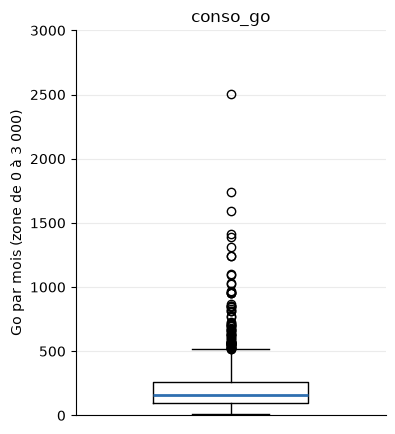

In [21]:
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(X["conso_go"].dropna(), widths=0.5, medianprops={"color": BLEU, "linewidth": 2})
ax.set_ylim(0, 3000)
ax.set_xticks([])
ax.set_ylabel("Go par mois (zone de 0 à 3 000)")
ax.set_title("conso_go")
plt.show()

### Le bilan des deux méthodes

Combien de clients chaque méthode signale-t-elle, colonne par colonne ?

In [22]:
lignes = []
for colonne, forme in [("age", "cloche"), ("mensualite", "cloche"), ("conso_go", "étalée")]:
    valeurs = X[colonne].dropna()
    basse, haute = bornes_quartiles(valeurs)
    lignes.append({
        "colonne": colonne,
        "forme": forme,
        "signalés par le z-score": int((z_score(valeurs).abs() > 3).sum()),
        "signalés par les quartiles": int(((valeurs < basse) | (valeurs > haute)).sum()),
    })
pd.DataFrame(lignes)

,colonne,forme,signalés par le z-score,signalés par les quartiles
0,age,cloche,5,12
1,mensualite,cloche,2,14
2,conso_go,étalée,3,75


| Forme de la colonne | Méthode | Pourquoi |
|---|---|---|
| en **cloche** (`age`, `mensualite`) | **z-score** | « plus de 3 écarts-types » veut dire « très rare », et il ne signale ici que des erreurs. Les quartiles, plus nerveux, ajoutent des clients normaux (un client de 85 ans, un abonnement à plus de 60 €) |
| **étalée** (`conso_go`) | **quartiles** | la moyenne et l'écart-type sont faussés par les valeurs extrêmes. Les quartiles, non |
| quelle que soit la forme | **les bornes du métier** | un contrat n'est pas signé avant 18 ans, un abonnement ne coûte pas 4 590 € |

### La décision : détecter n'est pas supprimer

On ne supprime pas un gros consommateur parce qu'il est loin des autres : c'est un vrai client.
On vide seulement les valeurs **impossibles**, avec des bornes fixées grâce au métier. Elles ne
dépendent d'aucun calcul sur les données, on peut donc les appliquer dès maintenant.
`mask` veut dire : « cache la valeur quand cette condition est vraie ».

In [23]:
vides_avant = X.isna().sum()

X["age"] = X["age"].mask((X["age"] < 18) | (X["age"] > 100))
X["mensualite"] = X["mensualite"].mask((X["mensualite"] < 5) | (X["mensualite"] > 200))
X["conso_go"] = X["conso_go"].mask(X["conso_go"] > 5000)

vides_apres = X.isna().sum()
(vides_apres - vides_avant)[vides_apres != vides_avant].rename("cases vidées")

age           5
mensualite    2
conso_go      3
Name: cases vidées, dtype: int64

Dix valeurs impossibles sont devenues des cases vides. Les gros consommateurs sont restés.
Ils seront traités plus loin, avec une borne apprise sur le train.

## 6. Les cases vides

Combien de cases vides, colonne par colonne ?

In [24]:
manquants = X.isna().sum()
pd.DataFrame({"cases vides": manquants, "part": (manquants / len(X)).round(3)})[manquants > 0]

,cases vides,part
age,65,0.043
mensualite,17,0.011
conso_go,48,0.032
satisfaction,180,0.120


Une décision par colonne, comme en séance 1 :

| Colonne | Forme | Décision | Pourquoi |
|---|---|---|---|
| `age`, `mensualite` | cloche | remplir avec la **médiane** | la moyenne ferait aussi l'affaire, la médiane ne bouge pas si une valeur extrême passe |
| `conso_go` | étalée | remplir avec la **médiane** | la moyenne serait tirée vers le haut par les gros consommateurs |
| `satisfaction` | texte, avec un ordre | remplir avec la réponse **la plus fréquente** | on ne peut pas calculer une médiane de mots. Autre choix possible : une catégorie « non répondu » |

La moyenne et la médiane de `conso_go` ne sont pas les mêmes :

In [25]:
X[["age", "mensualite", "conso_go"]].agg(["mean", "median"]).round(1)

,age,mensualite,conso_go
mean,45.8,40.0,209.2
median,46.0,40.2,155.6


Pour `conso_go`, la moyenne est nettement au-dessus de la médiane : c'est le signe d'une
distribution étalée vers la droite.

Voici ce que fait la médiane sur `age`. **On ne l'enregistre pas** : pour remplir une case,
il faut calculer une médiane, et la question est « calculée sur quels clients ? ». La partie 2
y répond.

In [26]:
age_rempli = X["age"].fillna(X["age"].median())
print("cases vides avant :", X["age"].isna().sum(), "     après :", age_rempli.isna().sum())

cases vides avant : 65      après : 0


## 7. Mettre les nombres à la même échelle

Pourquoi ? Un classifieur qui compare des clients en mesurant des **distances** (c'est le cas de
KNN, vu dans les slides) additionne des écarts. Prenons deux clients.

In [27]:
client_a = pd.Series({"age": 35, "anciennete_mois": 10, "conso_go": 120})
client_b = pd.Series({"age": 50, "anciennete_mois": 30, "conso_go": 270})
ecarts_types = X[["age", "anciennete_mois", "conso_go"]].std()

ecart_brut = client_b - client_a
ecart_en_sigma = ecart_brut / ecarts_types

pd.DataFrame({
    "écart brut": ecart_brut,
    "part de la distance (%)": (100 * ecart_brut ** 2 / (ecart_brut ** 2).sum()).round(1),
    "écart en écarts-types": ecart_en_sigma.round(2),
    "part de la distance, après (%)": (100 * ecart_en_sigma ** 2 / (ecart_en_sigma ** 2).sum()).round(1),
})

,écart brut,part de la distance (%),écart en écarts-types,"part de la distance, après (%)"
age,15,1.0,1.09,43.4
anciennete_mois,20,1.7,0.95,33.2
conso_go,150,97.3,0.80,23.4


Avant : 150 Go d'écart de consommation pèsent **97 %** de la distance, et 15 ans d'âge 1 %. Après avoir
exprimé chaque écart en écarts-types, les trois colonnes comptent pour 23 % à 43 % chacune. Voilà
pourquoi on met les colonnes à la même échelle.

Deux façons de le faire, vues en séance 1.

- **Normalisation** (min-max) : ramener entre 0 (le plus petit) et 1 (le plus grand).
- **Standardisation** : moyenne 0, écart-type 1. Chaque valeur devient son z-score.

On les compare sur `age` (en cloche) et `conso_go` (étalée).

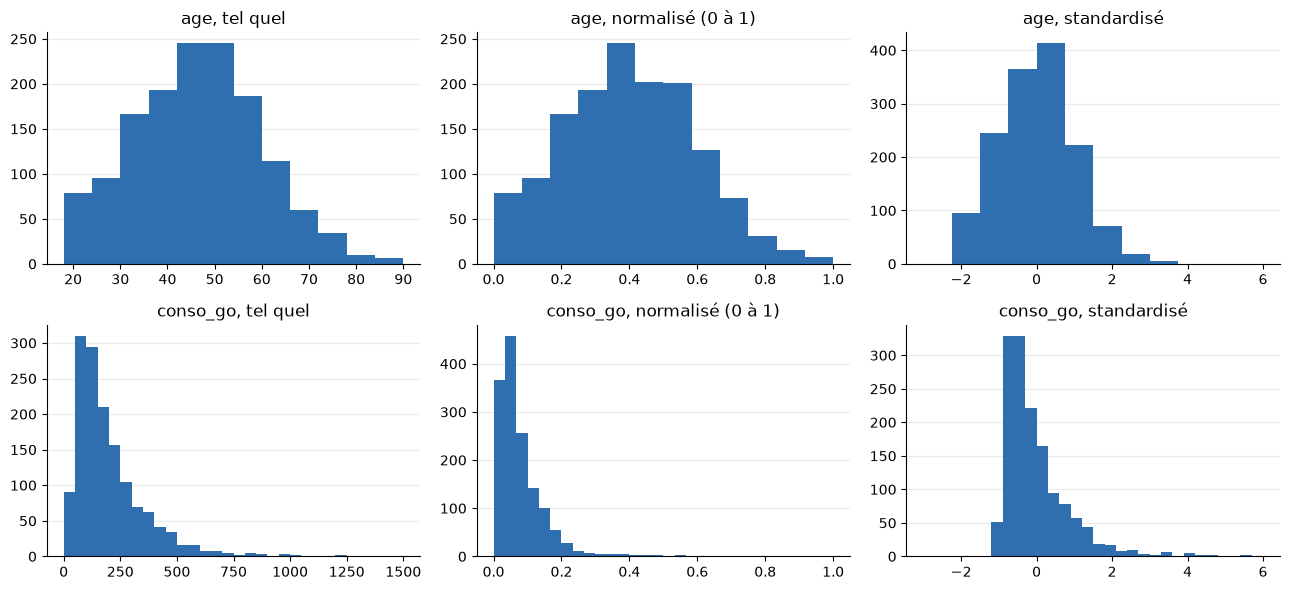

In [28]:
def normaliser(colonne):
    return (colonne - colonne.min()) / (colonne.max() - colonne.min())


def standardiser(colonne):
    return (colonne - colonne.mean()) / colonne.std(ddof=0)


fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ligne, (colonne, zone, barres) in enumerate([("age", (18, 90), 12), ("conso_go", (0, 1500), 30)]):
    valeurs = X[colonne].dropna()
    axes[ligne, 0].hist(valeurs, bins=barres, range=zone, color=BLEU)
    axes[ligne, 0].set_title(f"{colonne}, tel quel")
    axes[ligne, 1].hist(normaliser(valeurs), bins=barres, color=BLEU)
    axes[ligne, 1].set_title(f"{colonne}, normalisé (0 à 1)")
    axes[ligne, 2].hist(standardiser(valeurs), bins=barres, range=(-3, 6), color=BLEU)
    axes[ligne, 2].set_title(f"{colonne}, standardisé")
plt.tight_layout()
plt.show()

La **forme** ne change pas, seule l'échelle change. Mais regardez `conso_go` normalisé : presque
tous les clients sont tassés près de 0. Combien exactement ?

In [29]:
conso = X["conso_go"].dropna()
print("plus gros consommateur :", conso.max(), "Go")
print("part des clients sous 0,2 après normalisation :", round((normaliser(conso) < 0.2).mean(), 3))

plus gros consommateur : 2504.4 Go
part des clients sous 0,2 après normalisation : 0.948


Un seul client à 2 500 Go fixe le « 1 » : **95 %** des clients sont écrasés dans le premier
cinquième de l'échelle. La normalisation est **sensible aux valeurs extrêmes**. La
standardisation, qui n'a pas de bornes, s'en accommode mieux.

| | Normalisation | Standardisation |
|---|---|---|
| Résultat | entre 0 et 1 | moyenne 0, écart-type 1, sans bornes |
| Sensible aux valeurs extrêmes | oui | moins |
| Choisir quand | la colonne est bornée et sans extrême | la colonne est en cloche, ou a des extrêmes |

Dans ce notebook, on **standardise** les colonnes numériques.

## 8. Le texte que la machine ne sait pas lire

Un modèle ne calcule qu'avec des nombres. Pour chaque colonne de texte, une question : **y
a-t-il un ordre ?** On regarde le taux de résiliation dans chaque catégorie.

In [30]:
def taux_de_resiliation(colonne, ordre=None):
    taux = y.groupby(X[colonne]).mean()
    taux = taux.reindex(ordre) if ordre else taux.sort_values(ascending=False)
    return taux.round(2).rename("taux de résiliation")


ORDRE_CONTRAT = ["Mensuel", "1 an", "2 ans"]
ORDRE_SATISFACTION = ["Très insatisfait", "Insatisfait", "Neutre", "Satisfait", "Très satisfait"]

taux_de_resiliation("contrat", ORDRE_CONTRAT)

contrat
Mensuel    0.42
1 an       0.18
2 ans      0.08
Name: taux de résiliation, dtype: float64

In [31]:
taux_de_resiliation("satisfaction", ORDRE_SATISFACTION)

satisfaction
Très insatisfait    0.69
Insatisfait         0.41
Neutre              0.27
Satisfait           0.21
Très satisfait      0.08
Name: taux de résiliation, dtype: float64

### Avec un ordre : l'encodage ordinal

`contrat` et `satisfaction` ont un ordre, et le taux de résiliation **baisse régulièrement**
quand on le suit : plus l'engagement est long, moins on part ; plus on est satisfait, moins on
part. Des nombres qui respectent l'ordre (0, 1, 2...) disent la vérité, et le modèle pourra s'en
servir.

In [32]:
codes_contrat = {nom: code for code, nom in enumerate(ORDRE_CONTRAT)}
codes_satisfaction = {nom: code for code, nom in enumerate(ORDRE_SATISFACTION)}
print(codes_contrat)
print(codes_satisfaction)

pd.DataFrame({
    "contrat": X["contrat"],
    "code du contrat": X["contrat"].map(codes_contrat),
    "satisfaction": X["satisfaction"],
    "code de la satisfaction": X["satisfaction"].map(codes_satisfaction),
}).head(6)

{'Mensuel': 0, '1 an': 1, '2 ans': 2}
{'Très insatisfait': 0, 'Insatisfait': 1, 'Neutre': 2, 'Satisfait': 3, 'Très satisfait': 4}


,contrat,code du contrat,satisfaction,code de la satisfaction
0,2 ans,2,Neutre,2.0
1,1 an,1,Satisfait,3.0
2,1 an,1,NaN,NaN
3,Mensuel,0,NaN,NaN
4,Mensuel,0,Neutre,2.0
5,2 ans,2,Satisfait,3.0


Les cases vides de `satisfaction` restent vides (`NaN`) : elles seront remplies à l'étape
suivante.

### Sans ordre : l'encodage one-hot

`ville` et `mode_paiement` n'ont pas d'ordre. Les taux de résiliation ne suivent aucune
progression :

In [33]:
taux_de_resiliation("ville")

ville
Vesoul         0.32
Pontarlier     0.27
Montbéliard    0.27
Belfort        0.27
Besançon       0.26
Dole           0.19
Name: taux de résiliation, dtype: float64

Le **one-hot** crée une colonne par catégorie, avec 1 ou 0. Chaque client a un seul 1.

In [34]:
pd.get_dummies(X["ville"], prefix="ville", dtype=int).head(6)

,ville_Belfort,ville_Besançon,ville_Dole,ville_Montbéliard,ville_Pontarlier,ville_Vesoul
0,0,0,1,0,0,0
1,0,1,0,0,0,0
2,0,0,0,1,0,0
3,0,0,0,0,0,1
4,0,0,0,0,1,0
5,0,1,0,0,0,0


Pourquoi pas des codes 0, 1, 2... comme pour `contrat` ? Dans l'ordre alphabétique, cela
donnerait :

In [35]:
{ville: code for code, ville in enumerate(sorted(X["ville"].unique()))}

{'Belfort': 0,
 'Besançon': 1,
 'Dole': 2,
 'Montbéliard': 3,
 'Pontarlier': 4,
 'Vesoul': 5}

Le modèle croirait que Vesoul (5) est « plus grand » que Belfort (0), et que Dole (2) est « entre »
Besançon (1) et Montbéliard (3). Ces nombres **inventent un ordre qui n'existe pas**.

| Colonne | Ordre ? | Encodage |
|---|---|---|
| `contrat` | oui : Mensuel < 1 an < 2 ans | ordinal |
| `satisfaction` | oui : de très insatisfait à très satisfait | ordinal |
| `ville` | non | one-hot |
| `mode_paiement` | non | one-hot |

La partie 1 est terminée : le fichier est compris, mais **rien n'est encore appris**.

---
# Partie 2 · Préparer les données pour la classification

## 9. Pourquoi découper : train et test

Un modèle de classification **apprend** sur des exemples dont on connaît la réponse. Mais ce qui
nous intéresse, c'est qu'il se débrouille sur des clients **qu'il n'a jamais vus**. La seule
façon honnête de le savoir : lui cacher une partie des clients, et l'interroger dessus à la fin.

C'est la différence entre réviser avec les exercices du cours et passer l'examen : si
l'examen reprend les exercices déjà corrigés, la note ne prouve rien.

| | Rôle | Part habituelle |
|---|---|---|
| **train** (apprentissage) | le modèle **apprend** dessus, et on y calcule toute la préparation | 80 % |
| **test** | on le met de côté, et on ne l'ouvre qu'à la fin, **pour juger** | 20 % |

`train_test_split` fait le tirage au sort. Deux réglages :

- `random_state=42` : le tirage est le même à chaque exécution, chez vous comme ici.
- `stratify=y` : le train et le test ont la **même proportion** de clients qui résilient.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pd.DataFrame({
    "clients": [len(X_train), len(X_test)],
    "part qui résilie": [round(y_train.mean(), 3), round(y_test.mean(), 3)],
}, index=["train", "test"])

,clients,part qui résilie
train,1200,0.262
test,300,0.263


Pourquoi `stratify` ? Sans lui, le hasard peut donner un test avec trop peu, ou trop, de clients
qui résilient. Voici la part de résiliations dans le test, pour cinq tirages différents :

In [37]:
lignes = []
for graine in range(5):
    sans = train_test_split(X, y, test_size=0.2, random_state=graine)[3]
    avec = train_test_split(X, y, test_size=0.2, stratify=y, random_state=graine)[3]
    lignes.append({"tirage": graine, "sans stratify": round(sans.mean(), 3), "avec stratify": round(avec.mean(), 3)})
pd.DataFrame(lignes).set_index("tirage")

,sans stratify,avec stratify
tirage,,
0,0.273,0.263
1,0.253,0.263
2,0.293,0.263
3,0.253,0.263
4,0.257,0.263


Avec `stratify`, la proportion reste la même d'un tirage à l'autre : sans lui, elle bouge.

## 10. Ce qui change : on apprend sur le train, on applique au test

Toutes les préparations de la partie 1 **calculent quelque chose à partir des données** :

| Étape | Ce qui est calculé |
|---|---|
| remplir les cases vides | la médiane (ou la réponse la plus fréquente) |
| plafonner les valeurs extrêmes | la borne haute des quartiles |
| standardiser | la moyenne et l'écart-type |
| encoder | la liste des catégories |

Si on calcule cela sur **tout le fichier**, les clients du test participent à la préparation du
train : le modèle est jugé sur des clients dont il a, en partie, déjà « vu » les chiffres. C'est
la **fuite de données** (*data leakage*). Le résultat paraît meilleur qu'il n'est.

La règle tient en deux verbes :

- **`fit`** : calculer, **sur le train seulement**.
- **`transform`** : appliquer ce qui a été calculé, au train **et** au test.

Un objet de scikit-learn fait ces deux gestes. Regardons-le travailler, étape par étape, sur les
colonnes numériques.

### Cases vides : la médiane du train

In [38]:
from sklearn.impute import SimpleImputer

colonnes_nombres = ["age", "anciennete_mois", "mensualite", "conso_go", "nb_appels_support"]

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[colonnes_nombres])          # apprendre : calculé sur le train

pd.Series(imputer.statistics_, index=colonnes_nombres, name="médiane du train")

age                   46.00
anciennete_mois       25.00
mensualite            40.35
conso_go             157.70
nb_appels_support      1.00
Name: médiane du train, dtype: float64

In [39]:
vides_test = X_test[colonnes_nombres].isna().sum().sum()
test_rempli = imputer.transform(X_test[colonnes_nombres])    # appliquer, avec les médianes du train
print("cases vides dans le test, avant :", vides_test, "    après :", int(np.isnan(test_rempli).sum()))

cases vides dans le test, avant : 26     après : 0


Les cases vides du test ont été remplies avec les médianes **du train**. Le test ne fournit
aucune information : il reçoit.

### Valeurs extrêmes : la borne du train

Pour `conso_go`, on plafonne les gros consommateurs à la borne haute des quartiles. La borne
est calculée sur le train, puis utilisée telle quelle pour les deux.

In [40]:
q1, q3 = X_train["conso_go"].quantile([0.25, 0.75])
borne_haute_conso = q3 + 1.5 * (q3 - q1)

print("borne haute apprise sur le train :", round(borne_haute_conso), "Go")
print("clients plafonnés, train :", int((X_train["conso_go"] > borne_haute_conso).sum()),
      "    test :", int((X_test["conso_go"] > borne_haute_conso).sum()))

borne haute apprise sur le train : 517 Go
clients plafonnés, train : 57     test : 15


### Échelle : la moyenne et l'écart-type du train

In [41]:
from sklearn.preprocessing import StandardScaler

apprentissage = X_train[colonnes_nombres].copy()
jugement = X_test[colonnes_nombres].copy()

# plafonner, puis remplir, avec ce qui a été appris sur le train
apprentissage["conso_go"] = apprentissage["conso_go"].clip(upper=borne_haute_conso)
jugement["conso_go"] = jugement["conso_go"].clip(upper=borne_haute_conso)
apprentissage = pd.DataFrame(imputer.transform(apprentissage), columns=colonnes_nombres)
jugement = pd.DataFrame(imputer.transform(jugement), columns=colonnes_nombres)

scaler = StandardScaler()
scaler.fit(apprentissage)                        # apprendre : moyenne et écart-type du train

pd.DataFrame({"moyenne du train": scaler.mean_, "écart-type du train": scaler.scale_}, index=colonnes_nombres).round(1)

,moyenne du train,écart-type du train
age,45.7,13.3
anciennete_mois,29.2,20.8
mensualite,40.0,8.1
conso_go,194.7,129.7
nb_appels_support,1.2,1.1


In [42]:
apprentissage_std = pd.DataFrame(scaler.transform(apprentissage), columns=colonnes_nombres)
jugement_std = pd.DataFrame(scaler.transform(jugement), columns=colonnes_nombres)

pd.DataFrame({
    "moyenne, train": apprentissage_std.mean(),
    "écart-type, train": apprentissage_std.std(ddof=0),
    "moyenne, test": jugement_std.mean(),
    "écart-type, test": jugement_std.std(ddof=0),
}).round(2) + 0.0     # « + 0.0 » évite l'affichage « -0.0 »

,"moyenne, train","écart-type, train","moyenne, test","écart-type, test"
age,0.0,1.0,0.06,1.06
anciennete_mois,0.0,1.0,-0.02,1.05
mensualite,0.0,1.0,0.01,0.91
conso_go,0.0,1.0,-0.01,1.02
nb_appels_support,0.0,1.0,0.11,1.02


Sur le train : moyenne 0 et écart-type 1, par construction. Sur le test : **proche, sans être
exact**. C'est normal et voulu : le test a été transformé avec la moyenne et l'écart-type du
train, pas avec les siens. Si on le standardisait avec ses propres chiffres, un même client
n'aurait pas la même valeur selon qu'il est dans le train ou dans le test.

### Catégories : la liste du train

Un encodeur aussi apprend : la liste des catégories qu'il a vues.

In [43]:
from sklearn.preprocessing import OneHotEncoder

encodeur = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encodeur.fit(X_train[["ville"]])                 # apprendre : les villes du train

print("catégories apprises :", encodeur.categories_[0].tolist())
pd.DataFrame(encodeur.transform(X_test[["ville"]]), columns=encodeur.get_feature_names_out()).head(4)

catégories apprises : ['Belfort', 'Besançon', 'Dole', 'Montbéliard', 'Pontarlier', 'Vesoul']


,ville_Belfort,ville_Besançon,ville_Dole,ville_Montbéliard,ville_Pontarlier,ville_Vesoul
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0


Si une ville inconnue arrive un jour (`handle_unknown="ignore"`), elle reçoit des 0 partout au
lieu de faire planter le programme :

In [44]:
encodeur.transform(pd.DataFrame({"ville": ["Dijon"]}))

array([[0., 0., 0., 0., 0., 0.]])

C'est aussi la raison de ne pas utiliser `pd.get_dummies` pour le test : il ne connaît que les
catégories du tableau qu'on lui donne. Un test sans Belfort ni Vesoul donnerait **moins de
colonnes** que le train :

In [45]:
petit_train = pd.DataFrame({"ville": ["Belfort", "Dole", "Vesoul"]})
petit_test = pd.DataFrame({"ville": ["Dole", "Dole"]})

print("colonnes du train :", pd.get_dummies(petit_train["ville"]).columns.tolist())
print("colonnes du test  :", pd.get_dummies(petit_test["ville"]).columns.tolist())

colonnes du train : ['Belfort', 'Dole', 'Vesoul']
colonnes du test  : ['Dole']


## 11. Tout assembler : une chaîne de préparation

Faire ces gestes un par un est instructif, mais long, et facile à rater. scikit-learn les
assemble en **un seul objet** :

- un `Pipeline` enchaîne des étapes sur une même colonne (remplir, puis standardiser) ;
- un `ColumnTransformer` donne à **chaque groupe de colonnes** son propre traitement.

| Colonnes | Traitement |
|---|---|
| `conso_go` | plafonner, remplir (médiane), standardiser |
| `age`, `anciennete_mois`, `mensualite`, `nb_appels_support` | remplir (médiane), standardiser |
| `contrat`, `satisfaction` | remplir (la plus fréquente), encoder avec leur ordre |
| `ville`, `mode_paiement` | one-hot |

La fonction accepte `echelle=False` : nous en aurons besoin plus loin, pour voir ce que
vaut KNN sans standardisation.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder


def plafonner(valeurs):
    # np.minimum laisse passer les cases vides, qui seront remplies à l'étape suivante
    return np.minimum(valeurs, borne_haute_conso)


def traitement_nombres(echelle):
    etapes = [("vides", SimpleImputer(strategy="median"))]
    if echelle:
        etapes.append(("echelle", StandardScaler()))
    return etapes


def fabriquer_preparation(echelle=True):
    return ColumnTransformer([
        ("conso", Pipeline([("plafond", FunctionTransformer(plafonner, feature_names_out="one-to-one"))]
                           + traitement_nombres(echelle)), ["conso_go"]),
        ("nombres", Pipeline(traitement_nombres(echelle)),
         ["age", "anciennete_mois", "mensualite", "nb_appels_support"]),
        ("ordinales", Pipeline([
            ("vides", SimpleImputer(strategy="most_frequent")),
            ("codes", OrdinalEncoder(categories=[ORDRE_CONTRAT, ORDRE_SATISFACTION])),
        ]), ["contrat", "satisfaction"]),
        ("sans_ordre", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["ville", "mode_paiement"]),
    ]).set_output(transform="pandas")


preparation = fabriquer_preparation()

Un seul `fit`, sur le train. Un `transform` pour chacun des deux tableaux.

In [47]:
preparation.fit(X_train)

X_train_pret = preparation.transform(X_train)
X_test_pret = preparation.transform(X_test)

print("train :", X_train_pret.shape, "    test :", X_test_pret.shape)
X_train_pret.head(5).round(2).T

train : (1200, 17)     test : (300, 17)


,113,619,167,209,513
conso__conso_go,2.49,-0.65,0.85,-0.59,-0.13
nombres__age,0.17,1.30,-0.95,0.85,0.33
nombres__anciennete_mois,-0.25,-0.97,-0.97,3.21,-0.44
nombres__mensualite,-0.87,0.13,-2.37,-0.19,-1.57
nombres__nb_appels_support,-0.20,0.70,1.61,-0.20,2.51
ordinales__contrat,1.00,1.00,1.00,1.00,0.00
ordinales__satisfaction,2.00,2.00,2.00,4.00,0.00
sans_ordre__ville_Belfort,1.00,0.00,0.00,0.00,1.00
sans_ordre__ville_Besançon,0.00,0.00,0.00,1.00,0.00
sans_ordre__ville_Dole,0.00,0.00,0.00,0.00,0.00


17 colonnes, toutes numériques, sans case vide : 5 colonnes standardisées, 2 colonnes
ordinales, et 10 colonnes one-hot (6 villes, 4 modes de paiement). Le test a **exactement les
mêmes colonnes**. Cet objet fait-il bien la même chose que les gestes séparés de la section 10 ?

In [48]:
manuel = apprentissage_std.set_axis(X_train.index)
equivalents = {
    "age": "nombres__age", "anciennete_mois": "nombres__anciennete_mois", "mensualite": "nombres__mensualite",
    "nb_appels_support": "nombres__nb_appels_support", "conso_go": "conso__conso_go",
}
print("même résultat, colonne par colonne :",
      all(np.allclose(manuel[ancien], X_train_pret[nouveau]) for ancien, nouveau in equivalents.items()))
print("cases vides restantes :", int(X_train_pret.isna().sum().sum()), "dans le train,",
      int(X_test_pret.isna().sum().sum()), "dans le test")

même résultat, colonne par colonne : True
cases vides restantes : 0 dans le train, 0 dans le test


Le fichier est prêt : plus de texte, plus de case vide, des échelles comparables, et un test qui
n'a servi qu'à recevoir.

---
# Partie 3 · Classer, puis mesurer

## 12. Le point de départ : ne rien prédire

Avant d'essayer un vrai classifieur, il faut une **référence**. Le classifieur le plus bête :
il répond « reste » pour tout le monde (la classe la plus fréquente).

In [49]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

reference = Pipeline([("preparation", fabriquer_preparation()), ("modele", DummyClassifier(strategy="most_frequent"))])
reference.fit(X_train, y_train)
predictions = reference.predict(X_test)

print("clients du test :", len(y_test), "    dont partis :", int(y_test.sum()))
print("accuracy :", round(accuracy_score(y_test, predictions), 3))
print("clients partis repérés :", int(((predictions == 1) & (y_test == 1)).sum()))

clients du test : 300     dont partis : 79
accuracy : 0.737
clients partis repérés : 0


Ce modèle **ne fait rien** et a pourtant raison trois fois sur quatre : il n'a repéré aucun
client qui part, mais comme les clients qui restent sont les plus nombreux, la part de
bonnes réponses est élevée. C'est le piège des **classes déséquilibrées** du slide « Pièges à
éviter » : un modèle utile doit faire mieux que cette référence, **et** détecter les départs.

## 13. Un vrai classifieur : la régression logistique

On met la préparation et le modèle dans **un seul `Pipeline`**. Appeler `fit` sur le train
prépare le train (en apprenant la préparation), puis entraîne le modèle. Appeler `predict` sur le
test applique la préparation apprise, puis prédit.

In [50]:
from sklearn.linear_model import LogisticRegression

regression = Pipeline([("preparation", fabriquer_preparation()), ("modele", LogisticRegression(max_iter=1000))])
regression.fit(X_train, y_train)

predictions = regression.predict(X_test)
probabilites = regression.predict_proba(X_test)[:, 1]

Le modèle donne, pour chaque client, une **probabilité de résilier**. La prédiction est 1
(« résilie ») quand cette probabilité dépasse 0,5 : c'est le seuil par défaut. Voici les huit
premiers clients du test :

In [51]:
pd.DataFrame({
    "probabilité de résilier": probabilites[:8].round(2),
    "prédit": predictions[:8],
    "réel": y_test.to_numpy()[:8],
})

,probabilité de résilier,prédit,réel
0,0.02,0,0
1,0.38,0,0
2,0.62,1,1
3,0.09,0,1
4,0.54,1,1
5,0.15,0,0
6,0.46,0,1
7,0.02,0,0


## 14. La matrice de confusion

Pour chaque client du test, on compare la prédiction à la réalité. Quatre cas possibles :

| | Prédit : reste | Prédit : résilie |
|---|---|---|
| **Réel : reste** | **VN** : bien prédit | **FP** : fausse alerte |
| **Réel : résilie** | **FN** : départ manqué | **VP** : départ repéré |

(VP, VN, FP, FN : vrai positif, vrai négatif, faux positif, faux négatif. « Positif » = résilie.)

In [52]:
matrice = confusion_matrix(y_test, predictions)
vn, fp, fn, vp = matrice.ravel()
print("VN =", vn, "  FP =", fp, "  FN =", fn, "  VP =", vp)

VN = 208   FP = 13   FN = 44   VP = 35


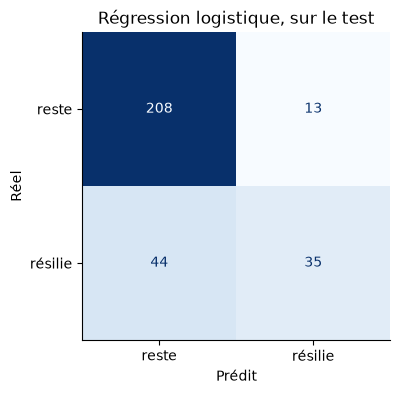

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4.6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, display_labels=["reste", "résilie"], cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Régression logistique, sur le test")
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.grid(False)
plt.show()

Le même tableau, dans les termes de l'entreprise :

- **VP** : des clients qui partaient, et que nous avions repérés. On peut leur proposer une offre.
- **FN** : des clients qui sont partis sans que nous le voyions. C'est le coût du modèle.
- **FP** : des clients qui seraient restés, et que nous avons contactés pour rien.
- **VN** : des clients qui restent, et que nous laissons tranquilles.

## 15. Les métriques

On calcule d'abord à la main, avec les formules du cours (le calcul sur l'exemple du spam, dans les slides).

In [54]:
accuracy = (vp + vn) / (vp + vn + fp + fn)
precision = vp / (vp + fp)
recall = vp / (vp + fn)
f1 = 2 * precision * recall / (precision + recall)

pd.DataFrame({
    "à la main": [accuracy, precision, recall, f1],
    "scikit-learn": [accuracy_score(y_test, predictions), precision_score(y_test, predictions),
                     recall_score(y_test, predictions), f1_score(y_test, predictions)],
}, index=["accuracy", "precision", "recall", "F1"]).round(3)

,à la main,scikit-learn
accuracy,0.810,0.810
precision,0.729,0.729
recall,0.443,0.443
F1,0.551,0.551


Les deux colonnes sont identiques. Comment lire ces quatre nombres :

- **accuracy** : part des clients bien classés. Elle paraît bonne, mais la référence « ne rien
  prédire » faisait déjà 0,74.
- **precision** : quand le modèle dit « résilie », à quelle fréquence a-t-il raison ?
- **recall** : parmi les clients qui partent vraiment, quelle part le modèle trouve-t-il ?
- **F1** : un équilibre entre precision et recall.

Ici, le **recall** est le chiffre qui pique : moins d'un client sur deux qui part est repéré.
`classification_report` donne tout d'un coup, pour chaque classe :

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, target_names=["reste", "résilie"]))

              precision    recall  f1-score   support

       reste       0.83      0.94      0.88       221
     résilie       0.73      0.44      0.55        79

    accuracy                           0.81       300
   macro avg       0.78      0.69      0.72       300
weighted avg       0.80      0.81      0.79       300



## 16. Le seuil : un réglage de l'entreprise

La probabilité de résilier est calculée. C'est **nous** qui fixons à partir de quelle valeur on
déclare « ce client va partir ». Le seuil de 0,5 n'a rien de sacré. Si contacter un client coûte
peu et perdre un client coûte cher, on a intérêt à **baisser** le seuil : on repère plus de
départs, au prix de plus de fausses alertes.

In [56]:
lignes = []
for seuil in [0.2, 0.3, 0.4, 0.5, 0.6]:
    predits = (probabilites >= seuil).astype(int)
    lignes.append({
        "seuil": seuil,
        "clients contactés": int(predits.sum()),
        "precision": round(precision_score(y_test, predits), 2),
        "recall": round(recall_score(y_test, predits), 2),
        "F1": round(f1_score(y_test, predits), 2),
    })
pd.DataFrame(lignes).set_index("seuil")

,clients contactés,precision,recall,F1
seuil,,,,
0.2,149,0.46,0.87,0.61
0.3,110,0.56,0.78,0.66
0.4,73,0.66,0.61,0.63
0.5,48,0.73,0.44,0.55
0.6,39,0.74,0.37,0.49


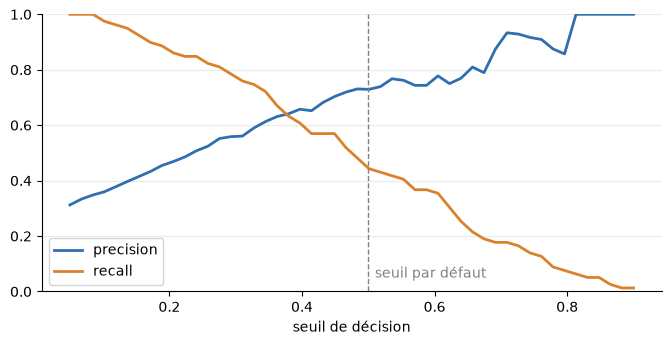

In [57]:
seuils = np.linspace(0.05, 0.9, 50)
precisions = [precision_score(y_test, probabilites >= s, zero_division=0) for s in seuils]
rappels = [recall_score(y_test, probabilites >= s) for s in seuils]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(seuils, precisions, color=BLEU, linewidth=2, label="precision")
ax.plot(seuils, rappels, color=ORANGE, linewidth=2, label="recall")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
ax.text(0.51, 0.05, "seuil par défaut", color="grey")
ax.set_xlabel("seuil de décision")
ax.set_ylim(0, 1)
ax.legend()
plt.show()

Quand le seuil monte, la precision monte (on ne signale que les cas sûrs) mais le recall
s'effondre (on en laisse partir beaucoup). Quand il baisse, c'est l'inverse. **On ne peut pas
avoir les deux** : le bon seuil dépend du coût d'une fausse alerte et du coût d'un départ
manqué, donc de l'entreprise, pas de l'algorithme.

---
# Partie 4 · Comparer, et se méfier

## 17. Trois classifieurs, la même préparation

Le slide « Quel algorithme choisir ? » compare KNN, la régression logistique et l'arbre de
décision. Essayons les trois sur ce fichier, avec **la même chaîne de préparation**.

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

modeles = {
    "KNN (5 voisins)": KNeighborsClassifier(n_neighbors=5),
    "Régression logistique": LogisticRegression(max_iter=1000),
    "Arbre de décision (profondeur 3)": DecisionTreeClassifier(max_depth=3, random_state=42),
}

resultats, predictions_par_modele = [], {}
for nom, modele in modeles.items():
    chaine = Pipeline([("preparation", fabriquer_preparation()), ("modele", modele)]).fit(X_train, y_train)
    predits = chaine.predict(X_test)
    predictions_par_modele[nom] = predits
    resultats.append({
        "modèle": nom,
        "accuracy": accuracy_score(y_test, predits),
        "precision": precision_score(y_test, predits),
        "recall": recall_score(y_test, predits),
        "F1": f1_score(y_test, predits),
    })
pd.DataFrame(resultats).set_index("modèle").round(3)

,accuracy,precision,recall,F1
modèle,,,,
KNN (5 voisins),0.770,0.614,0.342,0.439
Régression logistique,0.810,0.729,0.443,0.551
Arbre de décision (profondeur 3),0.767,0.636,0.266,0.375


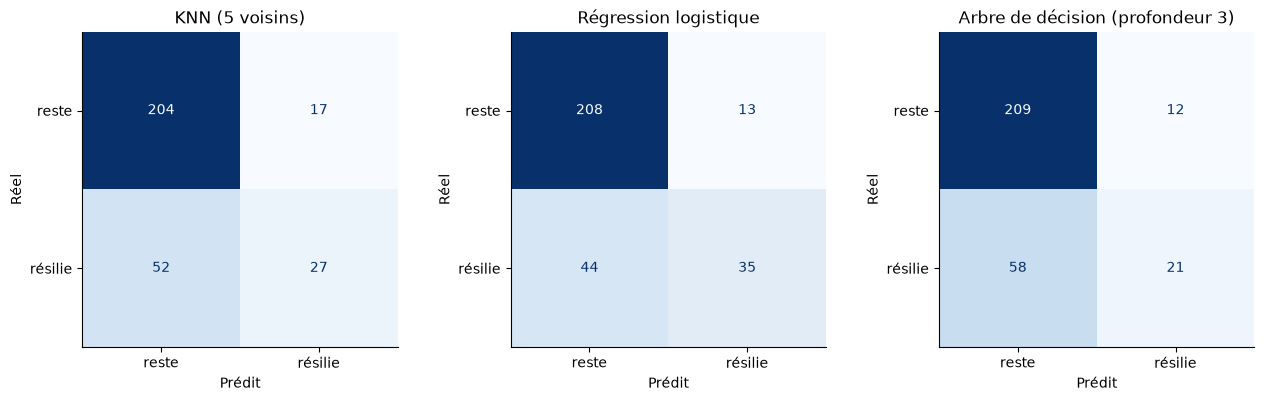

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (nom, predits) in zip(axes, predictions_par_modele.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, predits, display_labels=["reste", "résilie"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(nom)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.grid(False)
plt.tight_layout()
plt.show()

Aucun algorithme n'est « le meilleur » en général : ce classement vaut **pour ce fichier**. Ici,
la régression logistique est devant, ce qui n'a rien de surprenant : les liens entre les
colonnes et la résiliation sont plutôt réguliers (plus l'engagement est long, moins on part),
et c'est ce que sait bien capter un modèle linéaire.

## 18. KNN a besoin de l'échelle

KNN mesure des distances : sans standardisation, c'est la colonne aux plus grands nombres qui
décide (voir la partie 7). Le slide « Pièges à éviter » le disait : vérifions-le.

In [60]:
lignes = []
for echelle in [False, True]:
    chaine = Pipeline([("preparation", fabriquer_preparation(echelle=echelle)),
                       ("modele", KNeighborsClassifier(n_neighbors=5))]).fit(X_train, y_train)
    predits = chaine.predict(X_test)
    lignes.append({
        "KNN": "avec standardisation" if echelle else "sans standardisation",
        "accuracy": accuracy_score(y_test, predits),
        "recall": recall_score(y_test, predits),
        "F1": f1_score(y_test, predits),
    })
pd.DataFrame(lignes).set_index("KNN").round(3)

,accuracy,recall,F1
KNN,,,
sans standardisation,0.70,0.266,0.318
avec standardisation,0.77,0.342,0.439


Sans standardisation, tous les résultats baissent : KNN se trompe parce que la consommation en
Go (des centaines) et l'ancienneté en mois (des dizaines) écrasent l'âge, le nombre d'appels ou
le contrat. L'arbre de décision, lui, pose des questions du type « l'âge est-il sous 40 ans ? » :
l'échelle ne change pas ses réponses.

## 19. Le sur-ajustement

Un arbre de décision peut poser autant de questions qu'on veut. Plus il en pose, plus il colle
au train, jusqu'à **apprendre les clients par cœur**. Comparons le score sur le train et le
score sur le test, pour des arbres de plus en plus profonds.

In [61]:
profondeurs = [1, 2, 3, 4, 5, 6, 8, 10, None]
lignes = []
for profondeur in profondeurs:
    chaine = Pipeline([("preparation", fabriquer_preparation()),
                       ("modele", DecisionTreeClassifier(max_depth=profondeur, random_state=42))]).fit(X_train, y_train)
    lignes.append({
        "profondeur": "sans limite" if profondeur is None else profondeur,
        "accuracy sur le train": accuracy_score(y_train, chaine.predict(X_train)),
        "accuracy sur le test": accuracy_score(y_test, chaine.predict(X_test)),
    })
sur_ajustement = pd.DataFrame(lignes).set_index("profondeur")
sur_ajustement.round(3)

,accuracy sur le train,accuracy sur le test
profondeur,,
1,0.738,0.737
2,0.748,0.740
3,0.768,0.767
4,0.781,0.727
5,0.800,0.717
6,0.825,0.727
8,0.888,0.733
10,0.940,0.710
sans limite,1.000,0.717


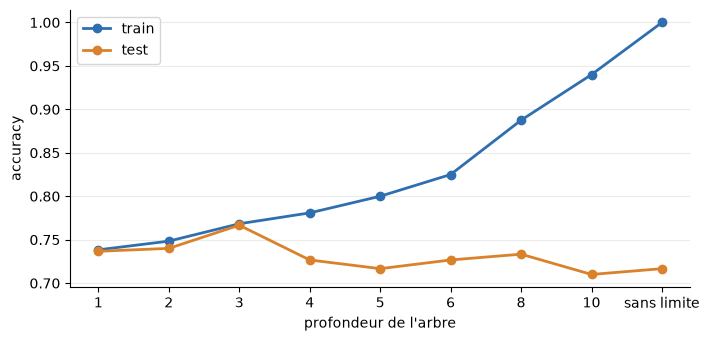

In [62]:
fig, ax = plt.subplots(figsize=(8, 3.6))
positions = range(len(sur_ajustement))
ax.plot(positions, sur_ajustement["accuracy sur le train"], color=BLEU, linewidth=2, marker="o", label="train")
ax.plot(positions, sur_ajustement["accuracy sur le test"], color=ORANGE, linewidth=2, marker="o", label="test")
ax.set_xticks(list(positions))
ax.set_xticklabels(sur_ajustement.index.astype(str))
ax.set_xlabel("profondeur de l'arbre")
ax.set_ylabel("accuracy")
ax.legend()
plt.show()

L'arbre sans limite obtient **1,00 sur le train** : il a tout retenu, y compris le hasard. Sur
le test, il fait moins bien (0,72) qu'un arbre à trois questions (0,77). Le score sur le train ne dit
rien de la qualité du modèle. **Seul le test, que le modèle n'a jamais vu, le dit.**

## 20. Et si le découpage était un coup de chance ?

Un seul découpage peut flatter, ou pénaliser, un modèle. La **validation croisée** découpe le
train en 5 morceaux : chacun sert à son tour de test, les quatre autres servent à apprendre.
On obtient cinq scores au lieu d'un.

In [63]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

decoupage = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(regression, X_train, y_train, cv=decoupage, scoring="f1")

print("F1 sur les 5 morceaux :", scores.round(2))
print("moyenne :", scores.mean().round(2), "    écart entre le plus bas et le plus haut :", (scores.max() - scores.min()).round(2))

F1 sur les 5 morceaux : [0.52 0.45 0.5  0.52 0.41]
moyenne : 0.48     écart entre le plus bas et le plus haut : 0.11


Le F1 change d'un morceau à l'autre : une mesure sur un seul découpage n'est qu'une estimation.
Remarquez aussi que `regression` est un `Pipeline` : à chaque morceau, la préparation est
**réapprise** sur les quatre morceaux d'apprentissage seulement. C'est une des grandes
raisons de tout mettre dans un pipeline : la préparation ne peut pas « fuiter » par accident.

## 21. Qu'a retenu le modèle ?

Les coefficients de la régression logistique disent comment chaque colonne pousse la
probabilité de résilier : vers le haut (positif) ou vers le bas (négatif). Comme les colonnes
numériques sont standardisées, leurs coefficients sont comparables entre eux.

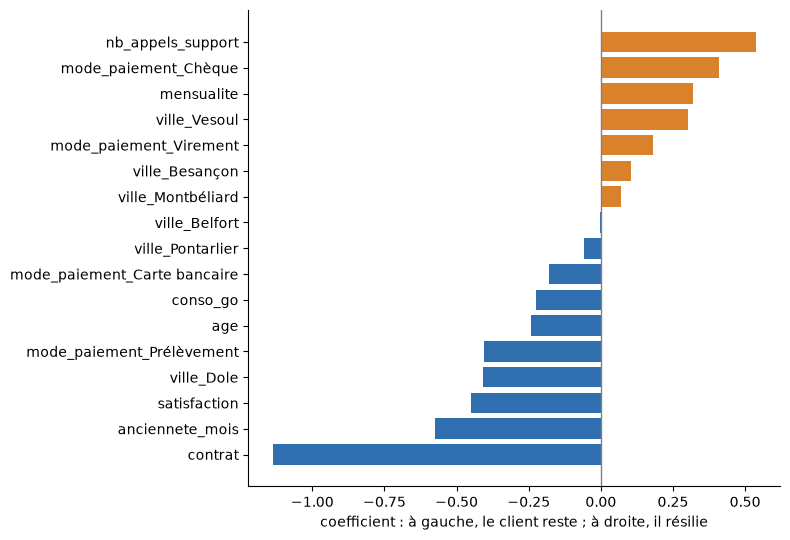

In [64]:
noms = regression.named_steps["preparation"].get_feature_names_out()
coefficients = pd.Series(regression.named_steps["modele"].coef_[0], index=noms).sort_values()
noms_courts = [nom.split("__")[-1] for nom in coefficients.index]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(noms_courts, coefficients.values, color=[ORANGE if c > 0 else BLEU for c in coefficients.values])
ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("coefficient : à gauche, le client reste ; à droite, il résilie")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Cela confirme ce que l'on a vu en regardant les taux de résiliation : le **contrat** pèse le plus,
puis l'**ancienneté**, le **nombre d'appels** au support et la **satisfaction**.

*Deux réserves.* Ces coefficients mêlent des colonnes standardisées et des colonnes à 0 ou 1 : la
comparaison donne un ordre de grandeur, pas une mesure exacte. Et les colonnes one-hot (ville, mode de
paiement) se lisent **les unes par rapport aux autres**, pas isolément : le coefficient d'une ville
n'a de sens que comparé à celui des autres villes.

---
## Ce qu'il faut retenir

**L'ordre des étapes**

1. Regarder le fichier : doublons, rôle de chaque colonne (cible, caractéristiques, à écarter).
2. Vider les valeurs **impossibles** avec les bornes du métier.
3. **Découper** : train et test, avec `stratify=y` et `random_state`.
4. **`fit` sur le train** : médianes, bornes, moyennes et écarts-types, catégories.
5. **`transform` sur le train et le test**, avec ce qui a été appris sur le train.
6. Entraîner le classifieur **sur le train**.
7. Juger **sur le test**, une seule fois.

**Les choix**

| Question | Réponse |
|---|---|
| Colonne en cloche ou étalée ? | cloche : z-score. Étalée : quartiles |
| Valeur extrême : à supprimer ? | seulement si elle est **impossible**. Un vrai client extrême reste |
| Moyenne ou médiane pour remplir ? | médiane, dès qu'il y a des valeurs extrêmes |
| Normaliser ou standardiser ? | standardiser, sauf colonne bornée et sans extrême |
| Texte avec un ordre ? | ordinal, avec l'ordre donné par vous. Texte sans ordre : one-hot |
| Colonne connue seulement après l'événement ? | la retirer, c'est la réponse déguisée |

**Lire un classifieur**

- L'**accuracy** seule trompe quand les classes sont déséquilibrées : comparez-la toujours à
  la référence « ne rien prédire ».
- **precision** et **recall** ne disent pas la même chose, et le **seuil** les fait bouger en sens
  inverse : le bon réglage est un choix d'entreprise.
- Le score sur le **train** ne prouve rien. Seul le **test** compte.
- **Tout mettre dans un `Pipeline`** : la préparation est apprise sur le bon tableau, et
  impossible à oublier.